In [ ]:
# Installation of some requirements
# %pip install albumentations
# %pip install ultralytics

In [ ]:
# Kaggle dataset download
# !kaggle datasets download juanthomaswijaya/indonesian-license-plate-dataset --path data --unzip

In [ ]:
# %matplotlib inline

In [1]:
import numpy as np
import torch # If you use PyTorch later for training
import random
import os

# Choose an integer seed (e.g., 42, 0, or any number)
SEED = 42

def set_all_seeds(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    # If you use PyTorch, uncomment these:
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)

In [15]:
import cv2
import albumentations as A
from glob import glob

# Paths
INPUT_DATA_ROOT = "../data/raw/Indonesian License Plate Dataset/"

input_images = os.path.join(INPUT_DATA_ROOT, "images")
input_labels = os.path.join(INPUT_DATA_ROOT, "labels")

# OUTPUT Paths (A new folder to store the augmented data, usually outside of 'raw')
OUTPUT_DATA_ROOT = "../data/processed/"

output_images = os.path.join(OUTPUT_DATA_ROOT, "images")
output_labels = os.path.join(OUTPUT_DATA_ROOT, "labels")

# --- END: Updated Paths ---

# Create output directories
os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

# Define augmentation pipeline
transform = A.Compose([
    A.Rotate(limit=5, p=0.5),
    A.Perspective(scale=(0.02, 0.05)),
    A.RandomBrightnessContrast(p=0.5),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.RandomScale(scale_limit=0.2, p=0.5),
],
bbox_params=A.BboxParams(
    format='yolo', 
    label_fields=['class_labels'],
    # Add clip=True to ensure all coordinates are strictly within [0.0, 1.0]
    clip=True,
    min_area=1.0
))

# Loop through all images
for subdir in os.listdir(input_images):
    # Construct the full paths for the current subdirectory
    current_input_image_dir = os.path.join(input_images, subdir)
    current_input_label_dir = os.path.join(input_labels, subdir)

    # 🛑 FIX 2: Create the corresponding output subdirectories
    current_output_image_dir = os.path.join(output_images, subdir)
    current_output_label_dir = os.path.join(output_labels, subdir)

    os.makedirs(current_output_image_dir, exist_ok=True)
    os.makedirs(current_output_label_dir, exist_ok=True)
    
    print(f"Processing directory: {subdir}")

    # Loop through all images in the subdirectory
    # Using os.path.join is safer than f-string concatenation for paths
    for img_path in glob(os.path.join(current_input_image_dir, "*.jpg")):
        filename = os.path.basename(img_path)
        
        # 🛑 FIX 1: Correctly construct the label path using the subdirectory path
        label_path = os.path.join(current_input_label_dir, filename.replace(".jpg", ".txt"))

        # Safety Check: Ensure the label file exists before proceeding
        if not os.path.exists(label_path):
            print(f"Warning: Label file not found for {filename} in {subdir}. Skipping.")
            continue
            
        # Read image and labels (continue with your original logic)
        image = cv2.imread(img_path)
        if image is None:
            print(f"Error: Could not read image {img_path}. Skipping.")
            continue
            
        h, w, _ = image.shape # This is for context, not strictly needed by the augmentation code

        # ... (rest of the label reading, augmentation, and saving logic) ...

        with open(label_path, "r") as f:
            labels = f.readlines()

        bboxes = []
        class_labels = []
        for label in labels:
            try:
                cls, x, y, bw, bh = map(float, label.strip().split())
                bboxes.append([x, y, bw, bh])
                class_labels.append(int(cls))
            except Exception as e:
                 # Added error handling for malformed lines
                print(f"Error processing label line in {label_path}: {e}. Skipping image.")
                continue

        # Apply transformation
        transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)

        aug_img = transformed['image']
        aug_bboxes = transformed['bboxes']
        aug_labels = transformed['class_labels']

        # 🛑 FIX 2 (Final Save): Save augmented files into the correct OUTPUT subdirectory
        
        # Adding 'aug_' prefix is good practice to distinguish augmented files
        aug_filename = f"aug_{filename}" 

        # Save augmented image
        save_path_img = os.path.join(current_output_image_dir, aug_filename)
        cv2.imwrite(save_path_img, aug_img)

        # Save updated YOLO labels
        save_path_lbl = os.path.join(current_output_label_dir, aug_filename.replace(".jpg", ".txt"))
        with open(save_path_lbl, "w") as f:
            for cls, bbox in zip(aug_labels, aug_bboxes):
                f.write(f"{cls} {' '.join(map(str, bbox))}\n")

print("✅ Data augmentation complete!")


/home/bryan_santosa/conda_envs/torchgpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing directory: test
Processing directory: train
Processing directory: val
✅ Data augmentation complete!


In [16]:
from ultralytics import YOLO
import torch

print("YOLO version:", YOLO._version)
print("CUDA available:", torch.cuda.is_available())
print("Device being used:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


YOLO version: 1
CUDA available: True
Device being used: NVIDIA GeForce RTX 3060 Laptop GPU


In [19]:
DATA_YAML_PATH = '../data.yaml'

target_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load a pre-trained YOLOv8-nano model
model = YOLO('yolov8n.pt')

model.model.to(target_device) 

# 3. Verify the change (using the reliable check)
first_param_device = next(model.model.parameters()).device

print("✅ Model device (PyTorch check):", first_param_device)

print("Starting YOLOv8 training...")
results = model.train(
    data=DATA_YAML_PATH,     # Path to the data configuration file
    epochs=40,              # Number of epochs (adjust as needed)
    imgsz=640,               # Input image size (standard for YOLO)
    batch=6,                # Batch size (reduce if you run out of GPU memory)
    name='lp_detection_v3',  # Name for the results folder in 'runs/detect
    # Optional: use the 'freeze' argument if you want to freeze the backbone 
    amp=True,
    device=0,  
    lr0=1e-3
)

print("Training complete. Results saved in runs/detect/lp_detection_v3")

✅ Model device (PyTorch check): cuda:0
Starting YOLOv8 training...
New https://pypi.org/project/ultralytics/8.3.233 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.223 🚀 Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937,

In [20]:
evaluate = model.val()

Ultralytics 8.3.223 🚀 Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.7±0.1 ms, read: 134.6±15.8 MB/s, size: 1701.0 KB)
val: Scanning /mnt/d/Uni/Semester 5/Computer Vision/Plate-Recognition/data/processed/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 119.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5it/s 4.7s0.4ss
                   all        100        179       0.98      0.961      0.993      0.729
Speed: 8.8ms preprocess, 7.5ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /mnt/d/Uni/Semester 5/Computer Vision/Plate-Recognition/notebooks/runs/detect/val4


columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
                              0          1          2          3          4
epoch                  1.000000   2.000000   3.000000   4.000000   5.000000
time                  21.254500  39.879400  58.225500  76.807000  94.631500
train/box_loss         1.495820   1.367810   1.340050   1.340440   1.330070
train/cls_loss         2.545190   1.470670   1.236440   1.130550   1.042730
train/dfl_loss         1.142130   1.064740   1.078760   1.048280   1.042080
metrics/precision(B)   0.950420   0.870700   0.957740   0.931430   0.960400
metrics/recall(B)      0.856820   0.827650   0.886350   0.910630   0.948410
metrics/mAP50(B)       0.959420   0.916750   0.957720   0.963430   0.979110
metrics/mAP50-95(B)    0.527450   0.561900   0.585330   0.611060   0.

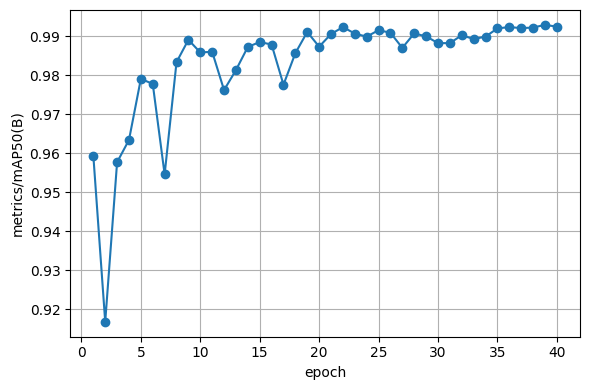

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("runs/detect/lp_detection_v3/results.csv")

# Inspect columns and head to see what's actually in the CSV
print("columns:", df.columns.tolist())
print(df.head().T)

# Pick the mAP column robustly
map_cols = [c for c in df.columns if "mAP50" in c or "map50" in c.lower() or "mAP" in c]
if not map_cols:
    raise ValueError("No mAP column found in results.csv. Columns: " + ", ".join(df.columns))
col = map_cols[0]
print("Using metric column:", col)

# Convert to numeric (coerce errors -> NaN) and warn if any NaNs
y = pd.to_numeric(df[col], errors="coerce")
if y.isnull().any():
    print("Warning: some values in the metric column could not be converted to numeric and became NaN")

# Use epoch column if present else use dataframe index
x = df["epoch"] if "epoch" in df.columns else df.index

plt.figure(figsize=(6,4))
plt.plot(x, y, marker="o")
plt.xlabel("epoch" if "epoch" in df.columns else "index")
plt.ylabel(col)
plt.grid(True)
plt.tight_layout()
plt.show()